In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
# clean train: remove duplicates and rows with missing values
train = train.drop_duplicates().dropna()

# clean test: can't score rows with no close, so drop those
test = test.dropna(subset=["close"])

# features: all columns except these
features = [c for c in train.columns if c not in ["date", "index", "symbols", "close"]]

# fill remaining gaps in test with the TRAIN average
for c in features:
    test[c] = test[c].fillna(train[c].mean())

In [4]:
X_train = train[features].values
y_train = train["close"].values
X_test = test[features].values
y_test = test["close"].values

In [5]:
#Scale features (using train's mean and std only)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [6]:
#Add a column of 1s for the bias term
X_train = np.c_[np.ones(len(X_train)), X_train]
X_test = np.c_[np.ones(len(X_test)), X_test]

In [7]:
#Accuracy = R2 score in %
def r2(y, y_pred):
    return 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)

In [8]:
#Gradient descent
w = np.zeros(X_train.shape[1])
lr = 0.1
epochs = 1000
costs = []

for i in range(epochs):
    pred = X_train @ w
    error = pred - y_train

    cost = np.mean(error ** 2) / 2
    costs.append(cost)

    w = w - lr * (X_train.T @ error) / len(y_train)

    train_acc = r2(y_train, X_train @ w) * 100
    test_acc = r2(y_test, X_test @ w) * 100
    print("Epoch", i + 1, "| Cost:", round(cost, 2),
          "| Train acc:", round(train_acc, 2), "| Test acc:", round(test_acc, 2))

Epoch 1 | Cost: 4926.98 | Train acc: 7.4 | Test acc: 2.85
Epoch 2 | Cost: 2621.46 | Train acc: 34.13 | Test acc: 25.44
Epoch 3 | Cost: 1864.69 | Train acc: 47.21 | Test acc: 35.75
Epoch 4 | Cost: 1494.4 | Train acc: 55.96 | Test acc: 42.72
Epoch 5 | Cost: 1246.82 | Train acc: 62.67 | Test acc: 48.24
Epoch 6 | Cost: 1056.91 | Train acc: 68.05 | Test acc: 52.79
Epoch 7 | Cost: 904.59 | Train acc: 72.42 | Test acc: 56.55
Epoch 8 | Cost: 780.75 | Train acc: 76.0 | Test acc: 59.65
Epoch 9 | Cost: 679.56 | Train acc: 78.92 | Test acc: 62.2
Epoch 10 | Cost: 596.65 | Train acc: 81.33 | Test acc: 64.31
Epoch 11 | Cost: 528.56 | Train acc: 83.31 | Test acc: 66.05
Epoch 12 | Cost: 472.49 | Train acc: 84.95 | Test acc: 67.51
Epoch 13 | Cost: 426.19 | Train acc: 86.3 | Test acc: 68.73
Epoch 14 | Cost: 387.83 | Train acc: 87.43 | Test acc: 69.77
Epoch 15 | Cost: 355.91 | Train acc: 88.37 | Test acc: 70.66
Epoch 16 | Cost: 329.24 | Train acc: 89.16 | Test acc: 71.43
Epoch 17 | Cost: 306.84 | Train ac

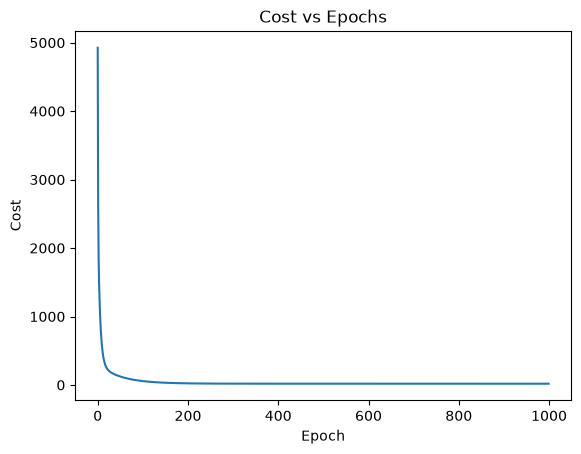

In [9]:
#Plot cost vs epochs
plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Cost vs Epochs")
plt.show()